# Tesla Valve Directional Asymmetry — LBM Source-of-Truth Notebook v3

This notebook replaces the reduced-order / illustrative vector-field proof channel with a D2Q9 lattice-Boltzmann solver.

Core test:

$$
q_{\Gamma,R}^{LBM} > q_{\Gamma,F}^{LBM}, \qquad Z_R^{LBM} > Z_F^{LBM}
$$

with

$$
q_\Gamma=\frac{\langle \omega^2\rangle_\Gamma}{\langle |u|^2\rangle_\Omega+\epsilon},
\qquad \omega=\partial_x u_y-\partial_y u_x
$$

and, at equal body-force drive,

$$
Z=\frac{|F_x|}{|Q|+\epsilon}.
$$

Nexus lock target:

$$
\Delta_{direction}\oplus\Gamma_{geometry}\rightarrow \{\Phi_F\text{ pass-through},\ E_R\text{ self-interference}\}.
$$

In [3]:
# ============================================================
# 0. Imports and configuration
# ============================================================
import math, json
from dataclasses import dataclass, asdict
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NX = 320
NY = 180
DEFAULT_FORCE = 8.0e-6
DEFAULT_TAU = 0.62
DEFAULT_STEPS = 2200
FORCE_SWEEP = [1.0e-6, 2.0e-6, 4.0e-6, 8.0e-6, 1.2e-5]
SWEEP_STEPS = 1600
DO_FORCE_SWEEP = True
DO_GEOMETRY_SEARCH = False
GEOM_SEARCH_N = 12
GEOM_SEARCH_STEPS = 900
SAVE_RESULTS = True
OUTDIR = Path('tesla_valve_lbm_v3_outputs')
OUTDIR.mkdir(exist_ok=True)
EPS = 1e-12
np.set_printoptions(precision=6, suppress=True)
print('Notebook initialized')
print(f'Grid={NX}x{NY}, tau={DEFAULT_TAU}, force={DEFAULT_FORCE}, steps={DEFAULT_STEPS}')
print(f'Output directory: {OUTDIR.resolve()}')

Notebook initialized
Grid=320x180, tau=0.62, force=8e-06, steps=2200
Output directory: D:\@User Data\Downloads\tesla_valve_lbm_v3_outputs


## 1. Geometry builder

White = fluid. Black = solid. The geometry is intentionally asymmetric: forward flow sees a steep branch, reverse flow sees a shallow scoop.

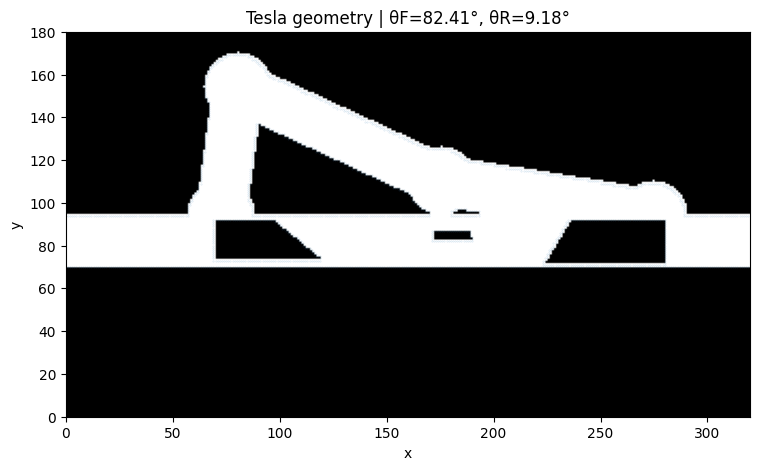

Fluid fraction: 0.2184201388888889
Interface fraction: 0.02486111111111111
{
  "nx": 320,
  "ny": 180,
  "main_y0": 70,
  "main_y1": 94,
  "A": [
    72,
    94
  ],
  "U1": [
    80,
    154
  ],
  "U2": [
    175,
    110
  ],
  "B": [
    274,
    94
  ],
  "loop_width": 24.0,
  "connector_radius": 16.0,
  "use_scoop_island": true,
  "use_return_island": true,
  "use_micro_notch": true
}


In [4]:
# ============================================================
# 1. Geometry builder
# ============================================================
@dataclass
class TeslaGeom:
    nx: int = NX
    ny: int = NY
    main_y0: int = 70
    main_y1: int = 94
    A: tuple = (72, 94)
    U1: tuple = (80, 154)
    U2: tuple = (175, 110)
    B: tuple = (274, 94)
    loop_width: float = 24.0
    connector_radius: float = 16.0
    use_scoop_island: bool = True
    use_return_island: bool = True
    use_micro_notch: bool = True

def add_segment(mask, p0, p1, width):
    ny, nx = mask.shape
    xs = np.arange(nx)[None, :]
    ys = np.arange(ny)[:, None]
    x0, y0 = p0; x1, y1 = p1
    vx, vy = x1-x0, y1-y0
    t = ((xs-x0)*vx + (ys-y0)*vy) / (vx*vx + vy*vy + EPS)
    t = np.clip(t, 0.0, 1.0)
    px, py = x0 + t*vx, y0 + t*vy
    mask[(xs-px)**2 + (ys-py)**2 <= (width/2.0)**2] = True
    return mask

def add_disk(mask, center, radius):
    ny, nx = mask.shape
    xs = np.arange(nx)[None, :]
    ys = np.arange(ny)[:, None]
    x, y = center
    mask[(xs-x)**2 + (ys-y)**2 <= radius**2] = True
    return mask

def polygon_mask(shape, points):
    ny, nx = shape
    xs = np.arange(nx)[None, :]
    ys = np.arange(ny)[:, None]
    inside = np.zeros((ny, nx), dtype=bool)
    pts = list(points); j = len(pts)-1
    for i in range(len(pts)):
        xi, yi = pts[i]; xj, yj = pts[j]
        cond = ((yi > ys) != (yj > ys)) & (xs < (xj-xi)*(ys-yi)/((yj-yi)+EPS) + xi)
        inside ^= cond
        j = i
    return inside

def make_tesla_fluid_mask(geom: TeslaGeom):
    fluid = np.zeros((geom.ny, geom.nx), dtype=bool)
    fluid[geom.main_y0:geom.main_y1+1, :] = True
    loop = [geom.A, geom.U1, geom.U2, geom.B]
    for p0, p1 in zip(loop[:-1], loop[1:]):
        add_segment(fluid, p0, p1, geom.loop_width)
    for p in loop:
        add_disk(fluid, p, geom.connector_radius)
    if geom.use_scoop_island:
        scoop = polygon_mask(fluid.shape, [(224, geom.main_y0+2), (280, geom.main_y0+2), (280, geom.main_y1-2), (236, geom.main_y1-2)])
        fluid[scoop] = False
    if geom.use_return_island:
        ret = polygon_mask(fluid.shape, [(70, geom.main_y0+4), (118, geom.main_y0+4), (96, geom.main_y1-2), (70, geom.main_y1-2)])
        fluid[ret] = False
    if geom.use_micro_notch:
        notch = polygon_mask(fluid.shape, [(172, geom.main_y0+12), (189, geom.main_y0+13), (188, geom.main_y0+17), (172, geom.main_y0+16)])
        fluid[notch] = False
    return fluid

def unit(v):
    v = np.asarray(v, dtype=float); return v/(np.linalg.norm(v)+EPS)

def angle_deg(v, w):
    return math.degrees(math.acos(float(np.clip(np.dot(unit(v), unit(w)), -1.0, 1.0))))

def geometry_angles(geom):
    A=np.array(geom.A, dtype=float); U1=np.array(geom.U1, dtype=float)
    U2=np.array(geom.U2, dtype=float); B=np.array(geom.B, dtype=float)
    return angle_deg([1,0], U1-A), angle_deg([-1,0], U2-B)

def wall_interface_mask(fluid):
    solid = ~fluid
    interface = np.zeros_like(fluid, dtype=bool)
    for dy in (-1,0,1):
        for dx in (-1,0,1):
            if dx==0 and dy==0: continue
            interface |= fluid & np.roll(np.roll(solid, dy, axis=0), dx, axis=1)
    return interface

def plot_geometry(geom, ax=None, title='Tesla geometry'):
    fluid = make_tesla_fluid_mask(geom)
    interface = wall_interface_mask(fluid)
    if ax is None:
        fig, ax = plt.subplots(figsize=(12,5))
    ax.imshow(fluid, origin='lower', cmap='gray', extent=[0, geom.nx, 0, geom.ny])
    yy, xx = np.where(interface)
    ax.scatter(xx, yy, s=0.08, alpha=0.22)
    ax.set_title(title); ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_aspect('equal')
    return ax

geom = TeslaGeom()
fluid = make_tesla_fluid_mask(geom)
theta_f, theta_r = geometry_angles(geom)
fig, ax = plt.subplots(figsize=(12,5))
plot_geometry(geom, ax=ax, title=f'Tesla geometry | θF={theta_f:.2f}°, θR={theta_r:.2f}°')
plt.show()
print('Fluid fraction:', fluid.mean())
print('Interface fraction:', wall_interface_mask(fluid).mean())
print(json.dumps(asdict(geom), indent=2))

## 2. D2Q9 BGK LBM solver

This is the source-of-truth path: solved velocity field → solved vorticity → measured $q_\Gamma$ and $Z$.

In [5]:
# ============================================================
# 2. D2Q9 BGK LBM solver
# ============================================================
C = np.array([[0,0],[1,0],[0,1],[-1,0],[0,-1],[1,1],[-1,1],[-1,-1],[1,-1]], dtype=int)
W = np.array([4/9,1/9,1/9,1/9,1/9,1/36,1/36,1/36,1/36], dtype=float)
OPP = np.array([0,3,4,1,2,7,8,5,6], dtype=int)

def lbm_feq(rho, ux, uy):
    out = np.empty(rho.shape + (9,), dtype=float)
    u2 = ux*ux + uy*uy
    for i, (cx, cy) in enumerate(C):
        cu = cx*ux + cy*uy
        out[..., i] = W[i]*rho*(1 + 3*cu + 4.5*cu*cu - 1.5*u2)
    return out

def guo_force_term(rho, ux, uy, fx, fy, tau):
    F = np.empty(rho.shape + (9,), dtype=float)
    pref = 1.0 - 0.5/tau
    for i, (cx, cy) in enumerate(C):
        ciu = cx*ux + cy*uy
        term = 3*((cx-ux)*fx + (cy-uy)*fy) + 9*ciu*(cx*fx + cy*fy)
        F[..., i] = pref*W[i]*term
    return F

def compute_macro(f, solid, fx=0.0, fy=0.0):
    rho = np.sum(f, axis=2)
    rho = np.where(rho <= EPS, 1.0, rho)
    momx = np.tensordot(f, C[:,0], axes=(2,0)) + 0.5*fx
    momy = np.tensordot(f, C[:,1], axes=(2,0)) + 0.5*fy
    ux = momx/rho; uy = momy/rho
    rho[solid] = 1.0; ux[solid] = 0.0; uy[solid] = 0.0
    return rho, ux, uy

def collide_and_stream(f, fluid, fx, fy, tau):
    solid = ~fluid
    rho, ux, uy = compute_macro(f, solid, fx, fy)
    feq = lbm_feq(rho, ux, uy)
    force = guo_force_term(rho, ux, uy, fx, fy, tau)
    f_post = f - (f-feq)/tau + force
    f_stream = np.empty_like(f_post)
    for i, (cx, cy) in enumerate(C):
        f_stream[..., i] = np.roll(np.roll(f_post[..., i], cy, axis=0), cx, axis=1)
    for i, (cx, cy) in enumerate(C):
        source_solid = np.roll(np.roll(solid, cy, axis=0), cx, axis=1)
        bounce = fluid & source_solid
        f_stream[bounce, i] = f_post[bounce, OPP[i]]
    feq_s = lbm_feq(np.ones_like(rho), np.zeros_like(ux), np.zeros_like(uy))
    f_stream[solid, :] = feq_s[solid, :]
    return f_stream

def measure_lbm(f, fluid, fx, fy, tau):
    solid = ~fluid
    rho, ux, uy = compute_macro(f, solid, fx, fy)
    U = ux.copy(); V = uy.copy(); U[solid] = np.nan; V[solid] = np.nan
    speed = np.sqrt(U*U + V*V)
    omega = np.gradient(np.nan_to_num(V), axis=1) - np.gradient(np.nan_to_num(U), axis=0)
    omega[solid] = np.nan
    interface = wall_interface_mask(fluid)
    mean_u2 = np.nanmean(speed[fluid]**2) + EPS
    q_bulk = np.nanmean(omega[fluid]**2) / mean_u2
    q_gamma = np.nanmean(omega[interface]**2) / mean_u2
    drive_sign = 1.0 if fx >= 0 else -1.0
    Q = drive_sign * np.nanmean(U[fluid])
    Q_abs = abs(Q)
    Z = abs(fx) / (Q_abs + EPS)
    nu = (tau - 0.5)/3.0
    H = float(np.sum(fluid[:, fluid.shape[1]//2]))
    Re_eff = Q_abs*H/(nu + EPS)
    return dict(rho=rho, U=U, V=V, speed=speed, omega=omega, interface=interface,
                q_bulk=q_bulk, q_Gamma=q_gamma, Q=Q, Q_abs=Q_abs, Z=Z, Re_eff=Re_eff,
                nu=nu, max_speed=np.nanmax(speed), mean_speed=np.nanmean(speed[fluid]),
                rho_min=np.nanmin(rho[fluid]), rho_max=np.nanmax(rho[fluid]))

def lbm_run(fluid, force_x, tau=DEFAULT_TAU, steps=DEFAULT_STEPS, force_y=0.0, report_every=250, stop_on_diverge=True):
    ny, nx = fluid.shape
    f = lbm_feq(np.ones((ny,nx), dtype=float), np.zeros((ny,nx), dtype=float), np.zeros((ny,nx), dtype=float))
    hist = []
    last_Q = None
    for step in range(steps):
        f = collide_and_stream(f, fluid, force_x, force_y, tau)
        if (step % report_every == 0) or (step == steps-1):
            m = measure_lbm(f, fluid, force_x, force_y, tau)
            Q = m['Q']; dQ = np.nan if last_Q is None else abs(Q-last_Q); last_Q = Q
            hist.append(dict(step=step, Q=Q, q_Gamma=m['q_Gamma'], q_bulk=m['q_bulk'], Z=m['Z'], Re_eff=m['Re_eff'], max_speed=m['max_speed'], rho_min=m['rho_min'], rho_max=m['rho_max'], dQ=dQ))
            if not np.all(np.isfinite(f)) or not np.isfinite(Q):
                if stop_on_diverge: raise FloatingPointError(f'LBM diverged at step {step}')
                print(f'LBM diverged at step {step}'); break
    out = measure_lbm(f, fluid, force_x, force_y, tau)
    out.update(dict(f=f, force_x=force_x, force_y=force_y, tau=tau, steps=steps, history=pd.DataFrame(hist), direction='forward' if force_x>0 else 'reverse'))
    return out

print('LBM core loaded')

LBM core loaded


## 3. Run one forward/reverse pair

Same geometry, same solver, same force magnitude: $F_x>0$ vs $F_x<0$.

In [6]:
# ============================================================
# 3. Single forward/reverse LBM pair
# ============================================================
def compare_lbm(forward, reverse):
    qf, qr = forward['q_Gamma'], reverse['q_Gamma']
    zf, zr = forward['Z'], reverse['Z']
    qbf, qbr = forward['q_bulk'], reverse['q_bulk']
    return dict(force_abs=abs(forward['force_x']), tau=forward['tau'], steps=forward['steps'],
                qGamma_forward=qf, qGamma_reverse=qr, DqGamma_R_over_F=qr/(qf+EPS), A_qGamma=(qr-qf)/(qr+qf+EPS),
                qBulk_forward=qbf, qBulk_reverse=qbr, DqBulk_R_over_F=qbr/(qbf+EPS),
                Q_forward=forward['Q_abs'], Q_reverse=reverse['Q_abs'], Q_ratio_R_over_F=reverse['Q_abs']/(forward['Q_abs']+EPS),
                Z_forward=zf, Z_reverse=zr, DZ_R_over_F=zr/(zf+EPS), A_Z=(zr-zf)/(zr+zf+EPS),
                Re_forward=forward['Re_eff'], Re_reverse=reverse['Re_eff'],
                rho_min_forward=forward['rho_min'], rho_max_forward=forward['rho_max'],
                rho_min_reverse=reverse['rho_min'], rho_max_reverse=reverse['rho_max'],
                max_speed_forward=forward['max_speed'], max_speed_reverse=reverse['max_speed'])

def print_lock(s):
    print(pd.Series(s).to_string())
    print()
    if s['DqGamma_R_over_F'] > 1.25 and s['DZ_R_over_F'] > 1.05:
        print('Ψ-LOCK: LBM shows reverse direction has higher interface eddy burden and higher impedance.')
    elif s['DqGamma_R_over_F'] > 1.0 and s['DZ_R_over_F'] > 1.0:
        print('Partial lock: LBM directionality exists, but it is weak.')
    else:
        print('Ω: LBM is reciprocal or inverted. Geometry/forcing is not yet a physical witness.')

forward = lbm_run(fluid, +DEFAULT_FORCE, tau=DEFAULT_TAU, steps=DEFAULT_STEPS, report_every=250)
reverse = lbm_run(fluid, -DEFAULT_FORCE, tau=DEFAULT_TAU, steps=DEFAULT_STEPS, report_every=250)
summary = compare_lbm(forward, reverse)
print('='*80); print('LBM SOURCE-OF-TRUTH TEST'); print('='*80)
print_lock(summary)
if SAVE_RESULTS:
    with open(OUTDIR/'lbm_single_pair_summary.json', 'w', encoding='utf-8') as f: json.dump(summary, f, indent=2)
    forward['history'].to_csv(OUTDIR/'lbm_forward_history.csv', index=False)
    reverse['history'].to_csv(OUTDIR/'lbm_reverse_history.csv', index=False)
    print(f'Saved summaries to {OUTDIR}')

LBM SOURCE-OF-TRUTH TEST
force_abs               0.000008
tau                     0.620000
steps                2200.000000
qGamma_forward          0.040740
qGamma_reverse          0.040743
DqGamma_R_over_F        1.000072
A_qGamma                0.000036
qBulk_forward           0.022153
qBulk_reverse           0.022163
DqBulk_R_over_F         1.000474
Q_forward               0.002962
Q_reverse               0.002964
Q_ratio_R_over_F        1.000488
Z_forward               0.002701
Z_reverse               0.002699
DZ_R_over_F             0.999513
A_Z                    -0.000244
Re_forward              3.850832
Re_reverse              3.852709
rho_min_forward         0.998389
rho_max_forward         1.001380
rho_min_reverse         0.998604
rho_max_reverse         1.001662
max_speed_forward       0.014638
max_speed_reverse       0.014684

Ω: LBM is reciprocal or inverted. Geometry/forcing is not yet a physical witness.
Saved summaries to tesla_valve_lbm_v3_outputs


## 4. Plot solved LBM fields

These plots use the actual solved LBM velocity field, not a renderer.

Saved: tesla_valve_lbm_v3_outputs\lbm_forward.png


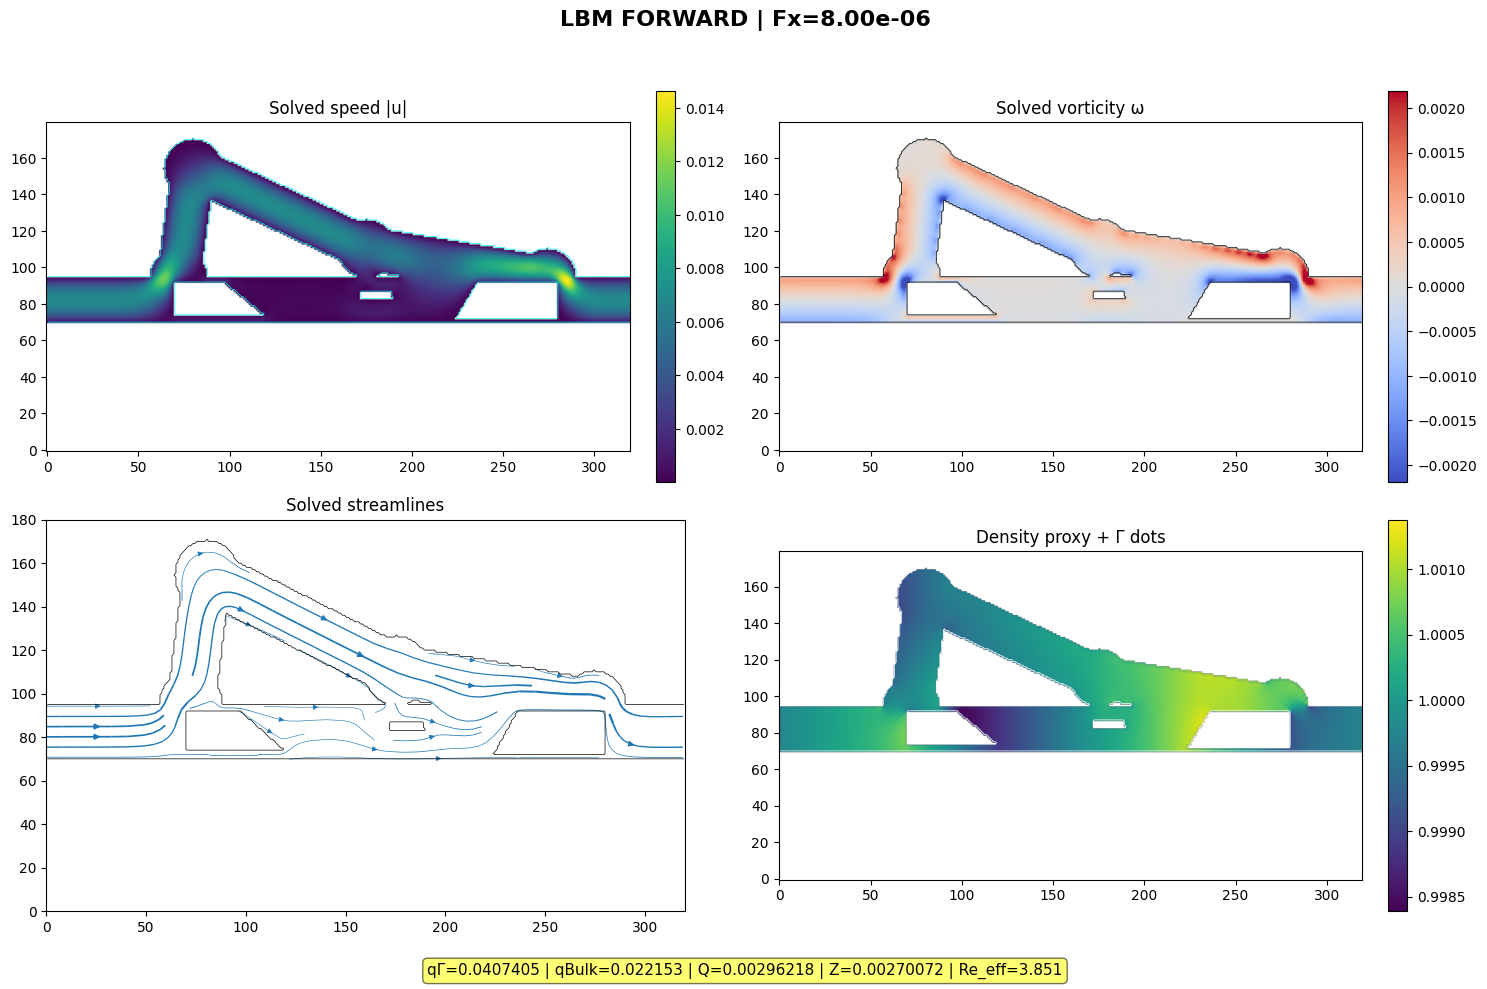

Saved: tesla_valve_lbm_v3_outputs\lbm_reverse.png


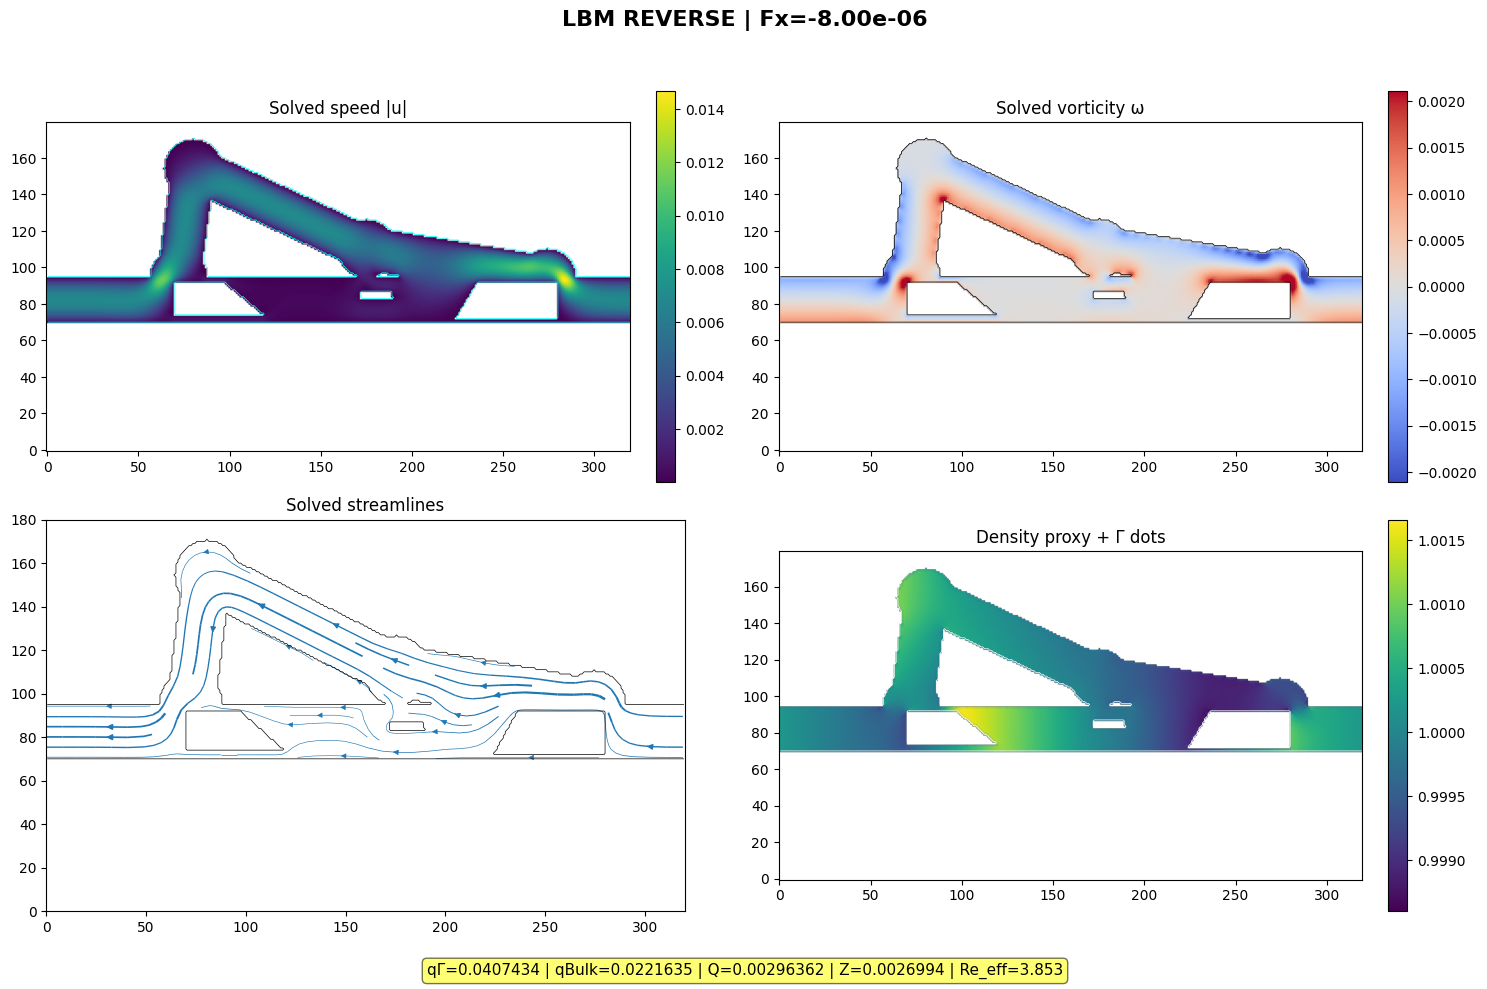

Saved: tesla_valve_lbm_v3_outputs\lbm_convergence_history.png


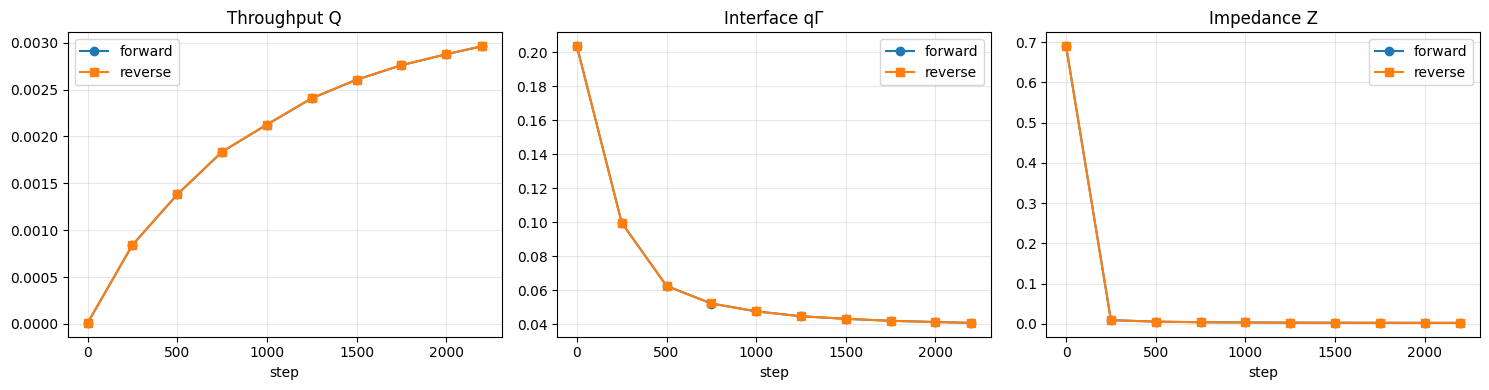

In [7]:
# ============================================================
# 4. Plot solved fields
# ============================================================
def plot_lbm_case(result, title=None, save_path=None):
    U,V,speed,omega,rho = result['U'], result['V'], result['speed'], result['omega'], result['rho'].copy()
    interface = result['interface']; fluid_plot = np.isfinite(speed)
    ny, nx = speed.shape
    if title is None: title = f"LBM {result['direction'].upper()} | Fx={result['force_x']:.2e}"
    fig = plt.figure(figsize=(15,10)); fig.suptitle(title, fontsize=16, fontweight='bold')
    ax1=fig.add_subplot(2,2,1); im1=ax1.imshow(speed, origin='lower'); ax1.contour(fluid_plot.astype(float), levels=[0.5], colors='cyan', linewidths=0.5, origin='lower'); ax1.set_title('Solved speed |u|'); fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
    ax2=fig.add_subplot(2,2,2); vmax=np.nanpercentile(np.abs(omega), 99); im2=ax2.imshow(omega, origin='lower', cmap='coolwarm', vmin=-vmax, vmax=vmax); ax2.contour(fluid_plot.astype(float), levels=[0.5], colors='k', linewidths=0.5, origin='lower'); ax2.set_title('Solved vorticity ω'); fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    ax3=fig.add_subplot(2,2,3); X,Y=np.meshgrid(np.arange(nx), np.arange(ny)); U0=np.nan_to_num(U); V0=np.nan_to_num(V)
    try:
        lw=0.4+1.8*np.nan_to_num(speed/(np.nanmax(speed)+EPS)); ax3.streamplot(X,Y,U0,V0,density=1.3,linewidth=lw,arrowsize=0.8)
    except Exception:
        skip=8; ax3.quiver(X[::skip,::skip],Y[::skip,::skip],U0[::skip,::skip],V0[::skip,::skip])
    ax3.contour(fluid_plot.astype(float), levels=[0.5], colors='k', linewidths=0.5, origin='lower'); ax3.set_xlim(0,nx); ax3.set_ylim(0,ny); ax3.set_title('Solved streamlines')
    ax4=fig.add_subplot(2,2,4); rho[~fluid_plot]=np.nan; im4=ax4.imshow(rho, origin='lower', cmap='viridis'); ax4.contour(fluid_plot.astype(float), levels=[0.5], colors='w', linewidths=0.5, origin='lower'); yy,xx=np.where(interface); ax4.scatter(xx,yy,s=0.1,alpha=0.25); ax4.set_title('Density proxy + Γ dots'); fig.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)
    fig.text(0.5,0.015,f"qΓ={result['q_Gamma']:.6g} | qBulk={result['q_bulk']:.6g} | Q={result['Q']:.6g} | Z={result['Z']:.6g} | Re_eff={result['Re_eff']:.3f}",ha='center',bbox=dict(boxstyle='round',facecolor='yellow',alpha=0.55),fontsize=11)
    plt.tight_layout(rect=[0,0.04,1,0.95])
    if save_path is not None:
        fig.savefig(save_path, dpi=180, bbox_inches='tight'); print(f'Saved: {save_path}')
    return fig

plot_lbm_case(forward, save_path=OUTDIR/'lbm_forward.png' if SAVE_RESULTS else None); plt.show()
plot_lbm_case(reverse, save_path=OUTDIR/'lbm_reverse.png' if SAVE_RESULTS else None); plt.show()

fig, axes = plt.subplots(1,3,figsize=(15,4))
axes[0].plot(forward['history']['step'], forward['history']['Q'], marker='o', label='forward'); axes[0].plot(reverse['history']['step'], reverse['history']['Q'], marker='s', label='reverse'); axes[0].set_title('Throughput Q'); axes[0].grid(True,alpha=0.3); axes[0].legend()
axes[1].plot(forward['history']['step'], forward['history']['q_Gamma'], marker='o', label='forward'); axes[1].plot(reverse['history']['step'], reverse['history']['q_Gamma'], marker='s', label='reverse'); axes[1].set_title('Interface qΓ'); axes[1].grid(True,alpha=0.3); axes[1].legend()
axes[2].plot(forward['history']['step'], forward['history']['Z'], marker='o', label='forward'); axes[2].plot(reverse['history']['step'], reverse['history']['Z'], marker='s', label='reverse'); axes[2].set_title('Impedance Z'); axes[2].grid(True,alpha=0.3); axes[2].legend()
for ax in axes: ax.set_xlabel('step')
plt.tight_layout()
if SAVE_RESULTS:
    fig.savefig(OUTDIR/'lbm_convergence_history.png', dpi=180, bbox_inches='tight'); print(f"Saved: {OUTDIR/'lbm_convergence_history.png'}")
plt.show()

## 5. Force/Reynolds sweep

Expected valve behavior: $D_q\approx1$ at low drive, then $D_q>1$ and $D_Z>1$ as inertial self-interference turns on.

--- force=1.00e-06, steps=1600 ---
force_abs               0.000001
tau                     0.620000
steps                1600.000000
qGamma_forward          0.042530
qGamma_reverse          0.042527
DqGamma_R_over_F        0.999949
A_qGamma               -0.000025
qBulk_forward           0.022231
qBulk_reverse           0.022231
DqBulk_R_over_F         1.000022
Q_forward               0.000335
Q_reverse               0.000335
Q_ratio_R_over_F        1.000062
Z_forward               0.002987
Z_reverse               0.002987
DZ_R_over_F             0.999938
A_Z                    -0.000031
Re_forward              0.435156
Re_reverse              0.435183
rho_min_forward         0.999789
rho_max_forward         1.000164
rho_min_reverse         0.999836
rho_max_reverse         1.000212
max_speed_forward       0.001644
max_speed_reverse       0.001646

Ω: LBM is reciprocal or inverted. Geometry/forcing is not yet a physical witness.
--- force=2.00e-06, steps=1600 ---
force_abs             

,force_abs,tau,steps,qGamma_forward,qGamma_reverse,DqGamma_R_over_F,A_qGamma,qBulk_forward,qBulk_reverse,DqBulk_R_over_F,...,DZ_R_over_F,A_Z,Re_forward,Re_reverse,rho_min_forward,rho_max_forward,rho_min_reverse,rho_max_reverse,max_speed_forward,max_speed_reverse
0,0.000001,0.62,1600,0.042530,0.042527,0.999949,-0.000025,0.022231,0.022231,1.000022,...,0.999938,-0.000031,0.435156,0.435183,0.999789,1.000164,0.999836,1.000212,0.001644,0.001646
1,0.000002,0.62,1600,0.042535,0.042531,0.999899,-0.000050,0.022232,0.022233,1.000044,...,0.999875,-0.000062,0.870232,0.870341,0.999579,1.000328,0.999671,1.000424,0.003287,0.003294
2,0.000004,0.62,1600,0.042555,0.042547,0.999806,-0.000097,0.022238,0.022240,1.000090,...,0.999750,-0.000125,1.739940,1.740376,0.999161,1.000656,0.999341,1.000851,0.006562,0.006593
3,0.000008,0.62,1600,0.042627,0.042613,0.999667,-0.000166,0.022263,0.022267,1.000183,...,0.999493,-0.000254,3.476150,3.477913,0.998335,1.001312,0.998676,1.001714,0.013149,0.013190
4,0.000012,0.62,1600,0.042738,0.042723,0.999630,-0.000185,0.022305,0.022311,1.000281,...,0.999223,-0.000388,5.205480,5.209527,0.997522,1.001969,0.998006,1.002588,0.019739,0.019763


Saved: tesla_valve_lbm_v3_outputs\lbm_force_sweep.csv


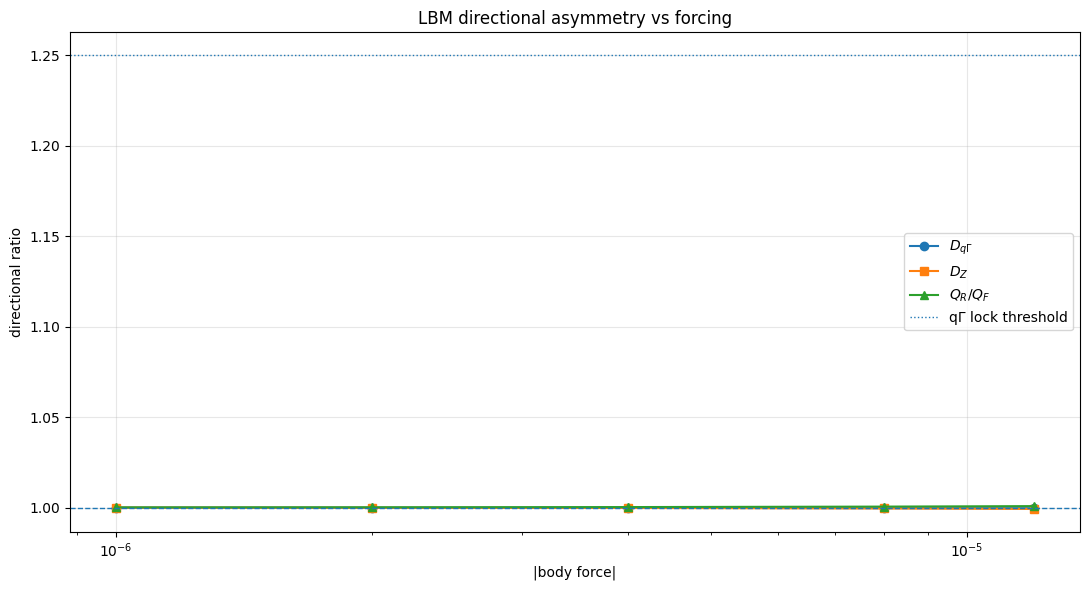

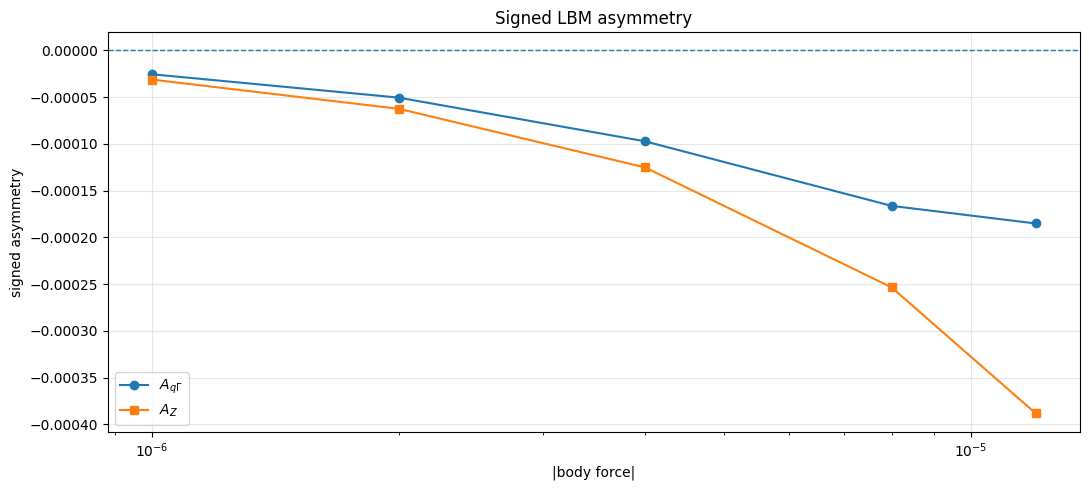

In [8]:
# ============================================================
# 5. Force/Reynolds sweep
# ============================================================
def run_force_sweep(fluid, forces=FORCE_SWEEP, tau=DEFAULT_TAU, steps=SWEEP_STEPS):
    rows=[]
    for force in forces:
        print(f'--- force={force:.2e}, steps={steps} ---')
        fwd=lbm_run(fluid,+force,tau=tau,steps=steps,report_every=max(200,steps//5))
        rev=lbm_run(fluid,-force,tau=tau,steps=steps,report_every=max(200,steps//5))
        s=compare_lbm(fwd,rev); print_lock(s); rows.append(s)
    return pd.DataFrame(rows)

if DO_FORCE_SWEEP:
    sweep_df = run_force_sweep(fluid)
    display(sweep_df)
    if SAVE_RESULTS:
        sweep_df.to_csv(OUTDIR/'lbm_force_sweep.csv', index=False); print(f"Saved: {OUTDIR/'lbm_force_sweep.csv'}")
    fig, ax = plt.subplots(figsize=(11,6))
    ax.plot(sweep_df['force_abs'], sweep_df['DqGamma_R_over_F'], marker='o', label=r'$D_{q\Gamma}$')
    ax.plot(sweep_df['force_abs'], sweep_df['DZ_R_over_F'], marker='s', label=r'$D_Z$')
    ax.plot(sweep_df['force_abs'], sweep_df['Q_ratio_R_over_F'], marker='^', label=r'$Q_R/Q_F$')
    ax.axhline(1.0, linestyle='--', linewidth=1); ax.axhline(1.25, linestyle=':', linewidth=1, label='qΓ lock threshold')
    ax.set_xscale('log'); ax.set_xlabel('|body force|'); ax.set_ylabel('directional ratio'); ax.set_title('LBM directional asymmetry vs forcing'); ax.grid(True, alpha=0.3); ax.legend(); plt.tight_layout()
    if SAVE_RESULTS: fig.savefig(OUTDIR/'lbm_force_sweep_ratios.png', dpi=180, bbox_inches='tight')
    plt.show()
    fig, ax = plt.subplots(figsize=(11,5))
    ax.plot(sweep_df['force_abs'], sweep_df['A_qGamma'], marker='o', label=r'$A_{q\Gamma}$')
    ax.plot(sweep_df['force_abs'], sweep_df['A_Z'], marker='s', label=r'$A_Z$')
    ax.axhline(0.0, linestyle='--', linewidth=1); ax.set_xscale('log'); ax.set_xlabel('|body force|'); ax.set_ylabel('signed asymmetry'); ax.set_title('Signed LBM asymmetry'); ax.grid(True, alpha=0.3); ax.legend(); plt.tight_layout()
    if SAVE_RESULTS: fig.savefig(OUTDIR/'lbm_force_sweep_asymmetry.png', dpi=180, bbox_inches='tight')
    plt.show()
else:
    print('DO_FORCE_SWEEP is False. Skipped.')

## 6. Optional LBM geometry mutation search

This is intentionally off by default. It mutates $U_1$ and $U_2$ and runs short LBM tests.

In [9]:
# ============================================================
# 6. Optional LBM geometry mutation search
# ============================================================
def mutate_geom(base, rng, scale=16):
    g=TeslaGeom(**asdict(base))
    U1x,U1y=g.U1; U2x,U2y=g.U2
    U1x += int(rng.normal(0,scale)); U1y += int(rng.normal(0,scale))
    U2x += int(rng.normal(0,scale)); U2y += int(rng.normal(0,scale))
    g.U1=(int(np.clip(U1x,74,145)), int(np.clip(U1y,116,g.ny-14)))
    g.U2=(int(np.clip(U2x,145,245)), int(np.clip(U2y,102,g.ny-35)))
    return g

def score_lbm_summary(s):
    return math.log(max(s['DqGamma_R_over_F'],EPS)) + 0.75*math.log(max(s['DZ_R_over_F'],EPS)) + 1.25*s['A_qGamma']

def run_geometry_search(base=geom, n=GEOM_SEARCH_N, force=DEFAULT_FORCE, tau=DEFAULT_TAU, steps=GEOM_SEARCH_STEPS, seed=11):
    rng=np.random.default_rng(seed); records=[]; candidates=[base]+[mutate_geom(base,rng) for _ in range(n)]
    for idx,g in enumerate(candidates):
        print(f'=== candidate {idx+1}/{len(candidates)} ===')
        tf,tr=geometry_angles(g); print(f'θF={tf:.2f}, θR={tr:.2f}, U1={g.U1}, U2={g.U2}')
        fl=make_tesla_fluid_mask(g)
        try:
            fwd=lbm_run(fl,+force,tau=tau,steps=steps,report_every=max(200,steps//3))
            rev=lbm_run(fl,-force,tau=tau,steps=steps,report_every=max(200,steps//3))
            s=compare_lbm(fwd,rev); sc=score_lbm_summary(s); print_lock(s)
            records.append({'score':sc,'geom':g,'theta_forward':tf,'theta_reverse':tr,**s})
        except Exception as exc:
            print('Candidate failed:', repr(exc))
            records.append({'score':-np.inf,'geom':g,'theta_forward':tf,'theta_reverse':tr,'error':repr(exc)})
    return sorted(records, key=lambda x:x['score'], reverse=True)

if DO_GEOMETRY_SEARCH:
    records=run_geometry_search(); top=records[0]
    print('TOP LBM GEOMETRY'); print('score:', top['score']); print(json.dumps(asdict(top['geom']), indent=2))
    serial=[]
    for r in records:
        d={k:v for k,v in r.items() if k!='geom'}; d['geom']=asdict(r['geom']); serial.append(d)
    if SAVE_RESULTS:
        with open(OUTDIR/'lbm_geometry_search.json','w',encoding='utf-8') as f: json.dump(serial,f,indent=2,default=str)
    fig, ax = plt.subplots(figsize=(12,5)); plot_geometry(top['geom'], ax=ax, title='Top LBM geometry'); plt.show()
else:
    print('DO_GEOMETRY_SEARCH is False. Skipped.')

DO_GEOMETRY_SEARCH is False. Skipped.


## 7. Ψ interpretation

Use the LBM summary, not the reduced-order model.

Lock:

$$
D_{q\Gamma}>1.25,\qquad D_Z>1.05
$$

Partial lock:

$$
D_{q\Gamma}>1,\qquad D_Z>1
$$

Ω:

$$
D_{q\Gamma}\approx1,\qquad D_Z\approx1
$$

The claim being tested is not “Tesla valve proves quantum gravity.” The claim is narrower and executable:

$$
\boxed{\text{same substrate + different direction + structured interface} \Rightarrow \text{different operational collapse}.}
$$